In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torch.optim as optim
import itertools

from models import SourceEncoder, TargetEncoder
from checkpoint_utils import (
    build_preprocess_info,
    capture_rng_state,
    load_dual_encoder_checkpoint,
    make_torch_generator,
    save_dual_encoder_checkpoint,
    set_reproducible_mode,
)

SEED = 42
DETERMINISTIC = True
set_reproducible_mode(SEED, deterministic=DETERMINISTIC)


In [5]:
categorical_cols = [
    'OCCAT1', 'OCCAT2', 'INDCAT', 'LF', 'HOUSECL', 'EDCL', 'EDUC',
    'AGECL', 'LIFECL', 'FAMSTRUCT', 'KIDS', 'MARRIED', 'EXPENSHILO', 'WSAVED',
    'SAVRES1', 'SAVRES2', 'SAVRES3', 'SAVRES4', 'SAVRES5',
    'SAVRES6', 'SAVRES7', 'SAVRES8', 'SAVRES9'
]

SPLIT = "train"   # train for training, test for evaluation

x_cat_tensor = torch.load(f'../dataset/processed/{SPLIT}_x_cat_tensor.pt')
x_ratio_tensor = torch.load(f'../dataset/processed/{SPLIT}_x_ratio_tensor.pt')
labels_tensor = torch.load(f'../dataset/processed/{SPLIT}_labels_tensor.pt')

current_categorical_cardinalities = torch.load(f'../dataset/processed/{SPLIT}_cardinalities.pt').tolist()
categorical_cardinalities = torch.load('../dataset/processed/train_cardinalities.pt').tolist()

print(x_cat_tensor.shape, x_ratio_tensor.shape, labels_tensor.shape)
print('current split cardinalities:', current_categorical_cardinalities)
print('train cardinalities:', categorical_cardinalities)


torch.Size([13207, 23]) torch.Size([13207, 4]) torch.Size([13207])
current split cardinalities: [5, 5, 5, 2, 3, 5, 15, 7, 7, 6, 11, 3, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2]
train cardinalities: [5, 5, 5, 2, 3, 5, 15, 7, 7, 6, 11, 3, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [6]:
# Define PyTorch DataLoader
class UserDataset(Dataset):
    def __init__(self, x_cat_tensor, x_ratio_tensor, labels_tensor):
        self.x_cat = x_cat_tensor
        self.x_ratio = x_ratio_tensor
        self.labels = labels_tensor
        
    def __len__(self):
        return len(self.x_cat)
        
    def __getitem__(self, idx):
        # 비금융 데이터, 금융 데이터, 5단계 라벨을 함께 반환
        return self.x_cat[idx], self.x_ratio[idx], self.labels[idx]

#### Run for training only

In [ ]:
# Create Dataset and DataLoader with the preprocessed tensors
dataset = UserDataset(x_cat_tensor, x_ratio_tensor, labels_tensor)
train_dataloader_generator = make_torch_generator(SEED)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True, generator=train_dataloader_generator) # Batch size is adjustable

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def symmetric_supcon_loss(z_NF, z_F, labels, temperature=0.1):
    """
    양방향(Symmetric) Supervised Contrastive Learning Loss
    비금융 -> 금융, 금융 -> 비금융 양쪽 방향의 정렬을 모두 최적화
    """
        
    # 1. 코사인 유사도 계산을 위한 L2 정규화
    z_NF = F.normalize(z_NF, dim=1)
    z_F = F.normalize(z_F, dim=1)
    
    # 2. 정답 마스크(Mask) 생성: 라벨이 같으면 1, 다르면 0
    labels = labels.contiguous().view(-1, 1)
    mask = torch.eq(labels, labels.T).float().to(device)
    
    mask_sum = mask.sum(dim=1)
    mask_sum = torch.max(mask_sum, torch.ones_like(mask_sum)) # 0 나누기 방지
    
    # 3. 비금융(NF) -> 금융(F) 방향
    sim_NF_F = torch.matmul(z_NF, z_F.T) / temperature
    log_prob_NF_F = F.log_softmax(sim_NF_F, dim=1)
    loss_NF_F = -((mask * log_prob_NF_F).sum(dim=1) / mask_sum).mean()

    # 4. 금융(F) -> 비금융(NF) 방향 (Symmetric)
    sim_F_NF = torch.matmul(z_F, z_NF.T) / temperature
    log_prob_F_NF = F.log_softmax(sim_F_NF, dim=1)
    loss_F_NF = -((mask * log_prob_F_NF).sum(dim=1) / mask_sum).mean()
    
    # 5. 양방향 Loss의 평균 반환
    return (loss_NF_F + loss_F_NF) / 2.0


In [ ]:
# 하이퍼파라미터 및 Early Stopping 설정

param_grid = {
    'batch_size': [256], # 256, 512, 1024
    'learning_rate': [1e-3], # 1e-3, 1e-4, 5e-5
    'temperature': [0.1], # 0.05, 0.1, 0.5
    'output_dim': [256], # 64, 128, 256
    'epochs': [300] # 100, 200
}

PATIENCE = 15       
MIN_DELTA = 0.001   

keys = param_grid.keys()
values = param_grid.values()
combinations = list(itertools.product(*values))

print(f"총 {len(combinations)}개의 조합을 탐색합니다. (Device: {device})")
print(f"조기 종료 조건: {PATIENCE} Epochs 동안 Loss 개선이 {MIN_DELTA} 미만일 경우 중단\n")

# Grid Search 루프 실행

best_overall_loss = float('inf')
best_params = None
training_preprocess_info = build_preprocess_info(
    categorical_cols=categorical_cols,
    categorical_cardinalities=categorical_cardinalities,
    x_cat_tensor=x_cat_tensor,
    x_ratio_tensor=x_ratio_tensor,
    labels_tensor=labels_tensor,
    split=SPLIT,
)

# unpack 순서를 param_grid의 key 순서와 동일하게 맞춤
for idx, (batch_size, lr, temp, out_dim, num_epochs) in enumerate(combinations):
    print(f"[{idx+1}/{len(combinations)}] {SPLIT}ing -> Batch: {batch_size}, LR: {lr}, Temp: {temp}, Dim: {out_dim}, Max Epochs: {num_epochs}")
    
    combo_seed = SEED + idx
    train_dataloader_generator = make_torch_generator(combo_seed)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, generator=train_dataloader_generator)
    
    # 모델 초기화 시 out_dim 변수를 적용
    source_encoder = SourceEncoder(categorical_cardinalities, embed_dim=16, output_dim=out_dim).to(device)
    target_encoder = TargetEncoder(input_dim=4, output_dim=out_dim).to(device)
    
    optimizer = optim.Adam(list(source_encoder.parameters()) + list(target_encoder.parameters()), lr=lr)
    
    best_epoch_loss = float('inf')
    epochs_no_improve = 0
    final_loss = float('inf')
    
    for epoch in range(num_epochs):
        source_encoder.train()
        target_encoder.train()
        
        total_loss = 0.0
        for batch_x_cat, batch_x_ratio, batch_labels in dataloader:
            batch_x_cat = batch_x_cat.to(device)
            batch_x_ratio = batch_x_ratio.to(device)
            batch_labels = batch_labels.to(device)
            
            optimizer.zero_grad()
            
            # 💡 수정된 부분: 두 인코더 모두 첫 번째 리턴값(h)은 버리고 두 번째(z)만 가져옵니다!
            _, z_NF = source_encoder(batch_x_cat)
            _, z_F = target_encoder(batch_x_ratio)
            
            # 이제 z_NF와 z_F 모두 64차원의 텐서이므로 에러 없이 깔끔하게 계산됩니다.
            loss = symmetric_supcon_loss(z_NF, z_F, batch_labels, temperature=temp)
            
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        avg_loss = total_loss / len(dataloader)
        
        if avg_loss < best_epoch_loss - MIN_DELTA:
            best_epoch_loss = avg_loss
            epochs_no_improve = 0 
        else:
            epochs_no_improve += 1 
            
        if (epoch + 1) % 10 == 0:
            print(f"  - Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f} (No improve: {epochs_no_improve}/{PATIENCE})")
            
        if epochs_no_improve >= PATIENCE:
            print(f"  Early Stopping - (Epoch {epoch+1}): 더 이상 학습이 진전되지 않습니다.")
            final_loss = best_epoch_loss
            break
            
        if epoch == num_epochs - 1:
            final_loss = avg_loss
            
    # 최고 성능 기록 및 모델 저장
    if final_loss < best_overall_loss:
        best_overall_loss = final_loss
        best_params = {
            'batch_size': batch_size, 
            'learning_rate': lr, 
            'temperature': temp, 
            'output_dim': out_dim,
            'epochs_run': epoch + 1,
            'seed': SEED,
            'dataloader_seed': combo_seed
        }
        print(f"  ★ New Best Loss 갱신! : {best_overall_loss:.4f}\n")
        
        save_dual_encoder_checkpoint(
            checkpoint_dir='../checkpoints',
            source_encoder=source_encoder,
            target_encoder=target_encoder,
            preprocess_info=training_preprocess_info,
            model_config={
                'embed_dim': 16,
                'output_dim': out_dim,
                'target_input_dim': x_ratio_tensor.shape[1],
            },
            best_params=best_params,
            best_loss=best_overall_loss,
            optimizer=optimizer,
            epoch=epoch + 1,
            rng_state=capture_rng_state(dataloader_generator=train_dataloader_generator),
            seed=SEED,
            deterministic=DETERMINISTIC,
        )
        print("  Saved checkpoint metadata: ../checkpoints/best_checkpoint_meta.json")
    else:
        print("\n") 

print(f"Grid Search 완료")
print(f"Best Loss: {best_overall_loss:.4f}")
print(f"Best Parameters: {best_params}")

총 1개의 조합을 탐색합니다. (Device: cpu)
조기 종료 조건: 15 Epochs 동안 Loss 개선이 0.001 미만일 경우 중단

[1/1] training -> Batch: 256, LR: 0.001, Temp: 0.1, Dim: 256, Max Epochs: 300
  - Epoch [10/300] Loss: 5.3975 (No improve: 0/15)
  - Epoch [20/300] Loss: 5.3678 (No improve: 0/15)
  - Epoch [30/300] Loss: 5.3284 (No improve: 0/15)
  - Epoch [40/300] Loss: 5.2907 (No improve: 1/15)
  - Epoch [50/300] Loss: 5.2572 (No improve: 0/15)
  - Epoch [60/300] Loss: 5.2336 (No improve: 1/15)
  - Epoch [70/300] Loss: 5.1979 (No improve: 0/15)
  - Epoch [80/300] Loss: 5.1811 (No improve: 1/15)
  - Epoch [90/300] Loss: 5.1546 (No improve: 0/15)
  - Epoch [100/300] Loss: 5.1431 (No improve: 1/15)
  - Epoch [110/300] Loss: 5.1250 (No improve: 1/15)
  - Epoch [120/300] Loss: 5.1104 (No improve: 1/15)
  - Epoch [130/300] Loss: 5.0979 (No improve: 0/15)
  - Epoch [140/300] Loss: 5.0856 (No improve: 0/15)
  - Epoch [150/300] Loss: 5.0771 (No improve: 5/15)
  - Epoch [160/300] Loss: 5.0681 (No improve: 1/15)
  - Epoch [170/300]

#### Load checkpoints

In [7]:
dataset = UserDataset(x_cat_tensor, x_ratio_tensor, labels_tensor)
dataloader = DataLoader(dataset, batch_size=512, shuffle=False)

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

try:
    source_encoder, target_encoder, checkpoint_meta, validation = load_dual_encoder_checkpoint(
        checkpoint_dir='../checkpoints',
        device=device,
        current_categorical_cols=categorical_cols,
        current_categorical_cardinalities=current_categorical_cardinalities,
        current_x_cat_tensor=x_cat_tensor,
        current_x_ratio_tensor=x_ratio_tensor,
        current_labels_tensor=labels_tensor,
        current_split=SPLIT,
        strict=True,
    )
    print("체크포인트 로드 완료")
    print("saved model config:", checkpoint_meta['model_config'])
    for warning in validation['warnings']:
        print("warning:", warning)
except FileNotFoundError:
    print("checkpoint metadata가 없어 기존 방식으로 로드합니다.")
    out_dim = 256
    source_encoder = SourceEncoder(
        categorical_cardinalities,
        embed_dim=16,
        output_dim=out_dim
    ).to(device)
    target_encoder = TargetEncoder(
        input_dim=4,
        output_dim=out_dim
    ).to(device)
    source_encoder.load_state_dict(
        torch.load('../checkpoints/best_source_encoder.pth', map_location=device)
    )
    target_encoder.load_state_dict(
        torch.load('../checkpoints/best_target_encoder.pth', map_location=device)
    )
    source_encoder.eval()
    target_encoder.eval()
    print("체크포인트 로드 완료 (메타데이터 검증 없음)")


체크포인트 로드 완료
saved model config: {'embed_dim': 16, 'output_dim': 256, 'target_input_dim': 4}


In [9]:
all_h_NF, all_z_NF = [], []
all_h_F, all_z_F = [], []
all_labels = []

with torch.no_grad():
    for batch_x_cat, batch_x_ratio, batch_labels in dataloader:
        batch_x_cat = batch_x_cat.to(device)
        batch_x_ratio = batch_x_ratio.to(device)

        h_NF, z_NF = source_encoder(batch_x_cat)
        h_F, z_F = target_encoder(batch_x_ratio)

        all_h_NF.append(h_NF.cpu())
        all_z_NF.append(z_NF.cpu())
        all_h_F.append(h_F.cpu())
        all_z_F.append(z_F.cpu())
        all_labels.append(batch_labels.cpu())

all_h_NF = torch.cat(all_h_NF, dim=0)
all_z_NF = torch.cat(all_z_NF, dim=0)
all_h_F = torch.cat(all_h_F, dim=0)
all_z_F = torch.cat(all_z_F, dim=0)
all_labels = torch.cat(all_labels, dim=0)

all_z_NF = F.normalize(all_z_NF, dim=1)
all_z_F = F.normalize(all_z_F, dim=1)
print("임베딩 추출 및 정규화 완료:", all_z_NF.shape, all_z_F.shape, all_labels.shape)

임베딩 추출 및 정규화 완료: torch.Size([13207, 64]) torch.Size([13207, 64]) torch.Size([13207])


### 시각화 및 유사도 검증

In [10]:
# 유사도 검증

sim_matrix = all_z_NF @ all_z_F.T

diag_sim = sim_matrix.diag().mean().item()

label_mask = all_labels[:, None] == all_labels[None, :]
same_label_sim = sim_matrix[label_mask].mean().item()
diff_label_sim = sim_matrix[~label_mask].mean().item()

top1_idx = sim_matrix.argmax(dim=1)
top1_label_acc = (all_labels[top1_idx] == all_labels).float().mean().item()

print(f"같은 샘플(source-target) 평균 유사도: {diag_sim:.4f}")
print(f"같은 라벨 평균 유사도: {same_label_sim:.4f}")
print(f"다른 라벨 평균 유사도: {diff_label_sim:.4f}")
print(f"Top-1 라벨 검색 정확도: {top1_label_acc:.4f}")

같은 샘플(source-target) 평균 유사도: 0.3721
같은 라벨 평균 유사도: 0.3689
다른 라벨 평균 유사도: 0.1531
Top-1 라벨 검색 정확도: 0.7201


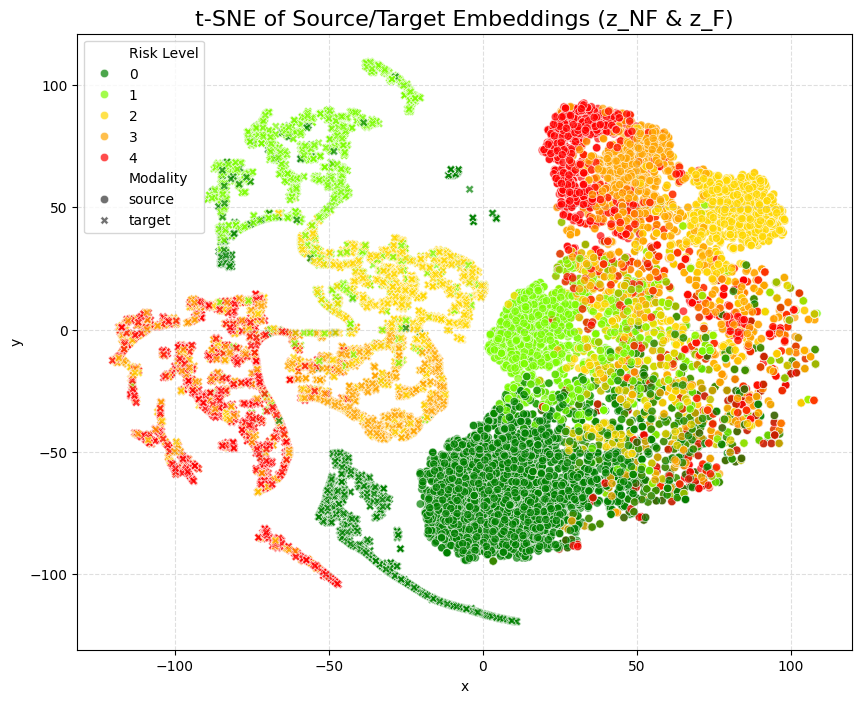

In [11]:
# t-SNE 시각화

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

emb = torch.cat([all_z_NF, all_z_F], dim=0).numpy()
modality = ['source'] * len(all_z_NF) + ['target'] * len(all_z_F)
risk = np.concatenate([all_labels.numpy(), all_labels.numpy()])

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d = tsne.fit_transform(emb)

df = pd.DataFrame({
    'x': emb_2d[:, 0],
    'y': emb_2d[:, 1],
    'Risk Level': risk,
    'Modality': modality,
})

risk_palette = {
    0: '#008000',
    1: '#7CFC00',
    2: '#FFD700',
    3: '#FFA500',
    4: '#FF0000',
}

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='x', y='y', hue='Risk Level', style='Modality', hue_order=[0, 1, 2, 3, 4], palette=risk_palette, alpha=0.7)
plt.title("t-SNE of Source/Target Embeddings (z_NF & z_F)", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

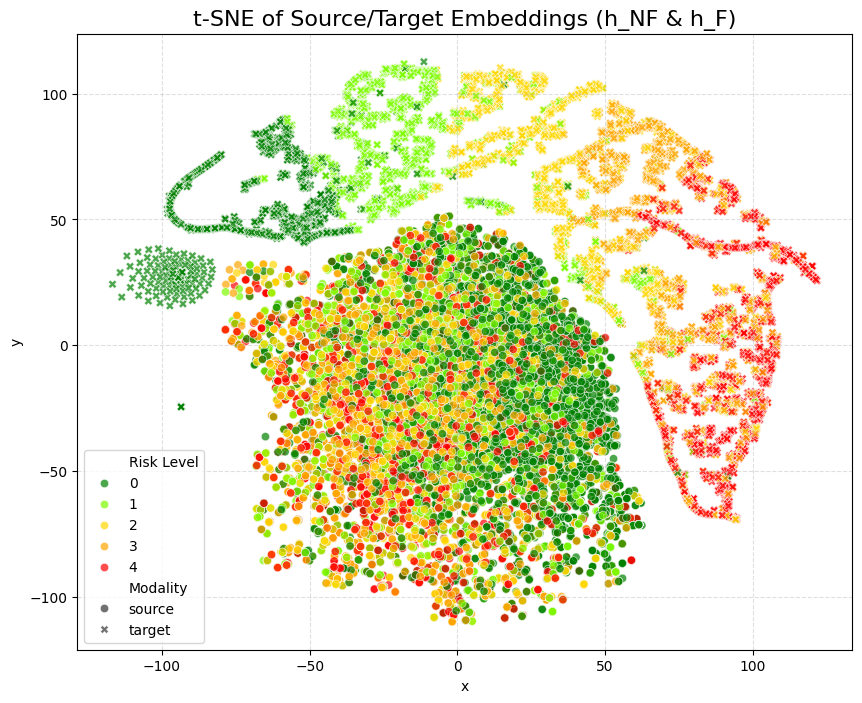

In [12]:
emb = torch.cat([all_h_NF, all_h_F], dim=0).numpy()
modality = ['source'] * len(all_h_NF) + ['target'] * len(all_h_F)
risk = np.concatenate([all_labels.numpy(), all_labels.numpy()])

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d = tsne.fit_transform(emb)

df = pd.DataFrame({
    'x': emb_2d[:, 0],
    'y': emb_2d[:, 1],
    'Risk Level': risk,
    'Modality': modality,
})

risk_palette = {
    0: '#008000',
    1: '#7CFC00',
    2: '#FFD700',
    3: '#FFA500',
    4: '#FF0000',
}

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='x', y='y', hue='Risk Level', style='Modality', hue_order=[0, 1, 2, 3, 4], palette=risk_palette, alpha=0.7)
plt.title("t-SNE of Source/Target Embeddings (h_NF & h_F)", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()